In [1]:
#plot cross recurrence plot
from pyunicorn.timeseries import RecurrencePlot, CrossRecurrencePlot
import recurrence as rec
from joblib import Parallel, delayed    
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp



In [2]:
# PARAMETERS

T = 15000
dt = 0.01
t_eval = np.linspace(0, T*dt, T)

TRANSIENT = 5000
END = 10000

# NORMALIZATION

def normalize_3d(ts):
    return (ts - np.mean(ts, axis=0)) / np.std(ts, axis=0)


# 1. NO SYNCHRONIZATION (Rössler–Rössler)

def roessler(t, state, a=0.2, b=0.2, c=5.7):
    x, y, z = state
    return [-y - z, x + a*y, b + (x - c)*z]

sol1 = solve_ivp(roessler, (0, T*dt), [1,1,1], t_eval=t_eval)
sol2 = solve_ivp(roessler, (0, T*dt), [2,2,2], t_eval=t_eval)

ts1_no = np.vstack(sol1.y).T[TRANSIENT:END]
ts2_no = np.vstack(sol2.y).T[TRANSIENT:END]

ts1_no = normalize_3d(ts1_no)
ts2_no = normalize_3d(ts2_no)


# 2. LAG SYNCHRONIZATION 

a, b, c = 0.2, 0.2, 5.7
k = 0.2
delay_steps = 1000

xd = np.zeros(T); yd = np.zeros(T); zd = np.zeros(T)
xr = np.zeros(T); yr = np.zeros(T); zr = np.zeros(T)

xd[0], yd[0], zd[0] = 1,1,1
xr[0], yr[0], zr[0] = 2,2,2

for i in range(T-1):
    # driver
    xd[i+1] = xd[i] + dt*(-yd[i] - zd[i])
    yd[i+1] = yd[i] + dt*(xd[i] + a*yd[i])
    zd[i+1] = zd[i] + dt*(b + zd[i]*(xd[i] - c))

    # delay
    xd_tau = xd[i-delay_steps] if i > delay_steps else xd[0]

    # response
    xr[i+1] = xr[i] + dt*(-yr[i] - zr[i] + k*(xd_tau - xr[i]))
    yr[i+1] = yr[i] + dt*(xr[i] + a*yr[i])
    zr[i+1] = zr[i] + dt*(b + zr[i]*(xr[i] - c))

ts1_ls = np.vstack((xd, yd, zd)).T[TRANSIENT:END]
ts2_ls = np.vstack((xr, yr, zr)).T[TRANSIENT:END]

ts1_ls = normalize_3d(ts1_ls)
ts2_ls = normalize_3d(ts2_ls)


# 3. PHASE SYNCHRONIZATION

def coupled_roessler(t, X, a=0.16, b=0.1, c=8.5, nu=0.02, mu=0.06):
    x1,x2,x3,y1,y2,y3 = X
    return [
        -(1+nu)*x2 - x3,
        (1+nu)*x1 + a*x2 + mu*(y2-x2),
        b + x3*(x1-c),
        -(1-nu)*y2 - y3,
        (1-nu)*y1 + a*y2 + mu*(x2-y2),
        b + y3*(y1-c)
    ]

sol_ps = solve_ivp(coupled_roessler, (0, T*dt), [1,1,1,2,2,2], t_eval=t_eval)

ts1_ps = np.vstack(sol_ps.y[:3]).T[TRANSIENT:END]
ts2_ps = np.vstack(sol_ps.y[3:]).T[TRANSIENT:END]

ts1_ps = normalize_3d(ts1_ps)
ts2_ps = normalize_3d(ts2_ps)


# 4. GENERALIZED SYNCHRONIZATION (Rössler to Lorenz)

def rossler_lorenz(t, state, eps=47):
    x1,y1,z1,x2,y2,z2 = state

    # Rössler (driver)
    dx1 = -(y1 + z1)
    dy1 = x1 + 0.2*y1
    dz1 = 0.2 + (x1 - 5.7)*z1

    # Lorenz (response)
    dx2 = 10*(y2 - x2) + eps*x1
    dy2 = x2*(28 - z2) - y2
    dz2 = x2*y2 - (8/3)*z2

    return [dx1,dy1,dz1,dx2,dy2,dz2]

sol_gs = solve_ivp(rossler_lorenz, (0, T*dt), [1,1,1,1,1,1], t_eval=t_eval)

ts1_gs = np.vstack(sol_gs.y[:3]).T[TRANSIENT:END]
ts2_gs = np.vstack(sol_gs.y[3:]).T[TRANSIENT:END]

ts1_gs = normalize_3d(ts1_gs)
ts2_gs = normalize_3d(ts2_gs)


# FUNCTION: CRP + JRP (3D)

def compute_crp_jrp(ts1, ts2):
    crp = CrossRecurrencePlot(ts1, ts2, recurrence_rate=0.1)
    CR = crp.recurrence_matrix()

    rp1 = RecurrencePlot(ts1, recurrence_rate=0.1)
    rp2 = RecurrencePlot(ts2, recurrence_rate=0.1)

    JR = rp1.recurrence_matrix() * rp2.recurrence_matrix()
    return CR, JR

CR_no, JR_no = compute_crp_jrp(ts1_no, ts1_no) #here use the same time series for complete synchronization.
CR_ls, JR_ls = compute_crp_jrp(ts1_ls, ts2_ls)
CR_ps, JR_ps = compute_crp_jrp(ts1_ps, ts2_ps)
CR_gs, JR_gs = compute_crp_jrp(ts1_gs, ts2_gs)


Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the supremum distance matrix...
Calculating cross recurrence plot at fixed recurrence rate...
Calculating the supr

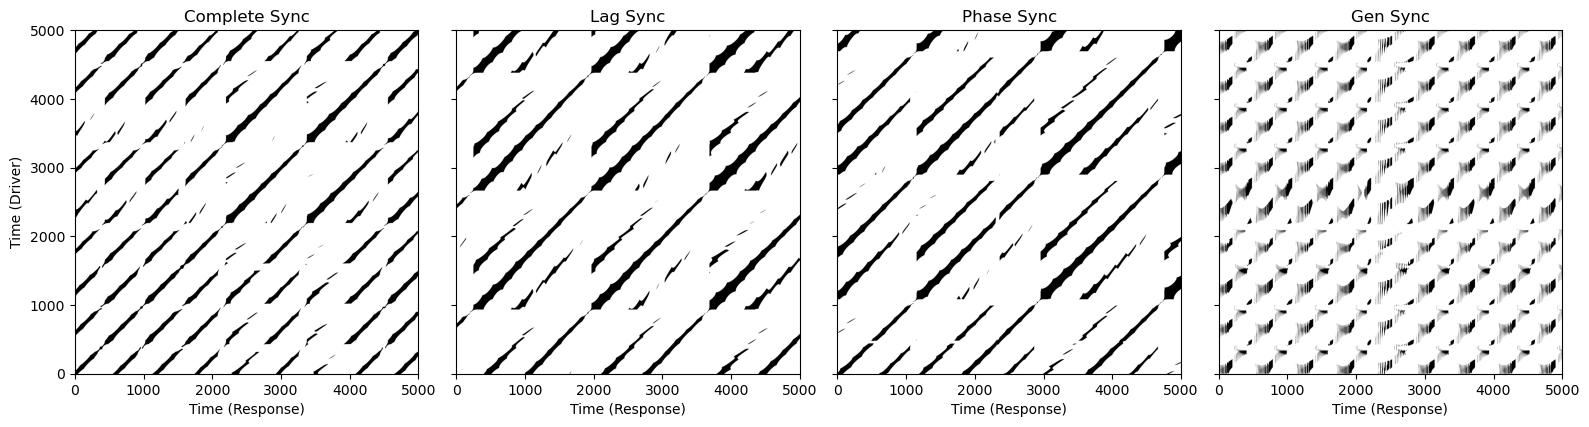

In [ ]:
# PLOT CRP

tick_positions = np.linspace(0, CR_no.shape[0], 6)
tick_labels = np.linspace(0, 5000, 6).astype(int)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

titles = ["Complete Sync", "Lag Sync", "Phase Sync", "Gen Sync"]

CR_list = [CR_no, CR_ls, CR_ps, CR_gs]
JR_list = [JR_no, JR_ls, JR_ps, JR_gs]

# CRP row
for i in range(4):
    axes[i].imshow(CR_list[i], origin='lower', cmap='binary')
    axes[i].set_title(titles[i])

    axes[i].set_xticks(tick_positions)
    axes[i].set_yticks(tick_positions)
    axes[i].set_xticklabels(tick_labels)
    axes[i].set_yticklabels(tick_labels)
    axes[i].set_xlabel("Time (Response)")
    if i == 0:
        axes[i].set_ylabel("Time (Driver)")
    else:
        axes[i].set_yticklabels([])

# # JRP row
# for i in range(4):
#     axes[1,i].imshow(JR_list[i], origin='lower', cmap='binary')
    
#     axes[1,i].set_xticks(tick_positions)
#     axes[1,i].set_yticks(tick_positions)
#     axes[1,i].set_xticklabels(tick_labels)
#     axes[1,i].set_yticklabels(tick_labels)

# axes[0,0].set_ylabel("CRP (3D phase space)")
# axes[1,0].set_ylabel("JRP (3D phase space)")


plt.tight_layout()
# plt.savefig("crp_all.pdf", dpi=300)
plt.show()

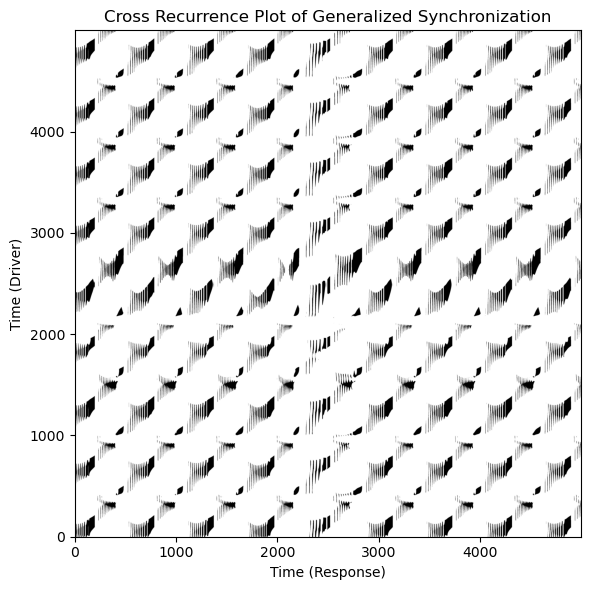

In [ ]:
#PLOT CRP GS
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(CR_gs, origin='lower', cmap='binary')
ax.set_title("Cross Recurrence Plot of Generalized Synchronization")
ax.set_xlabel("Time (Response)")
ax.set_ylabel("Time (Driver)")

# Save if needed
fig.savefig("CRP_GS.pdf", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

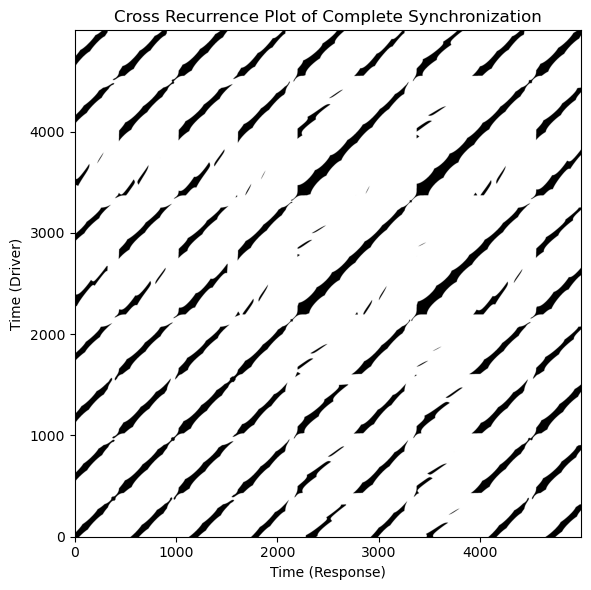

In [22]:
#PLOT CRP CS
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(CR_no, origin='lower', cmap='binary')
ax.set_title("Cross Recurrence Plot of Complete Synchronization")
ax.set_xlabel("Time (Response)")
ax.set_ylabel("Time (Driver)")

# Save if needed
fig.savefig("CRP_CS.pdf", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

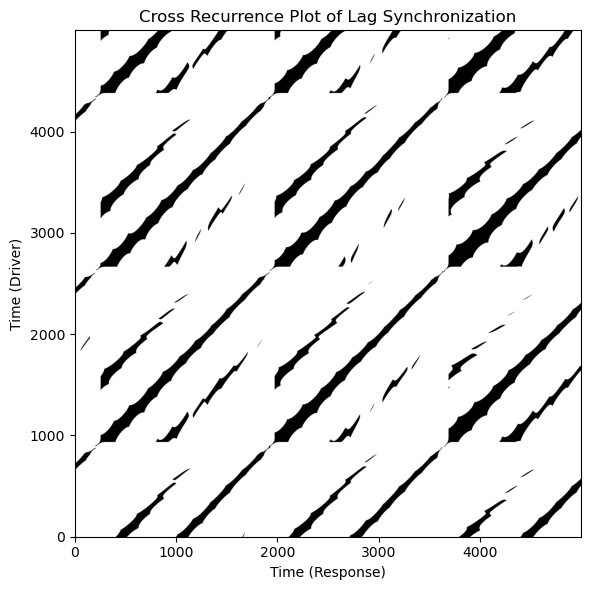

In [23]:
#PLOT CRP LS
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(CR_ls, origin='lower', cmap='binary')
ax.set_title("Cross Recurrence Plot of Lag Synchronization")
ax.set_xlabel("Time (Response)")
ax.set_ylabel("Time (Driver)")

# Save if needed
fig.savefig("CRP_LS.pdf", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

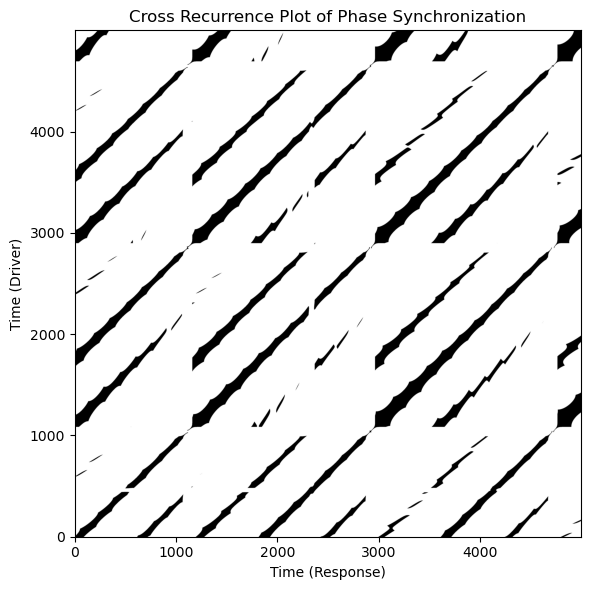

In [24]:
#PLOT CRP PS
fig, ax = plt.subplots(figsize=(6, 6))

ax.imshow(CR_ps, origin='lower', cmap='binary')
ax.set_title("Cross Recurrence Plot of Phase Synchronization")
ax.set_xlabel("Time (Response)")
ax.set_ylabel("Time (Driver)")

# Save if needed
fig.savefig("CRP_PS.pdf", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

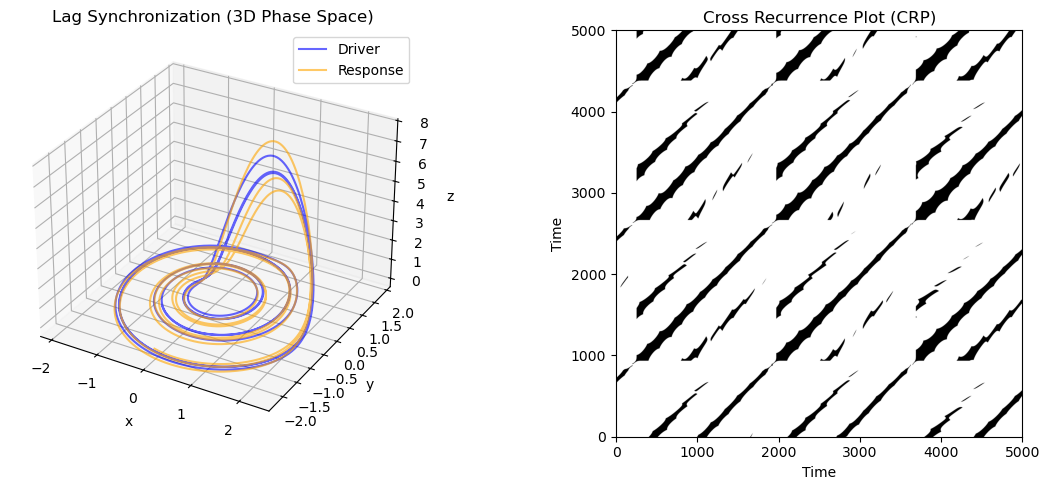

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# ticks
tick_positions = np.linspace(0, CR_ls.shape[0]-1, 6)
tick_labels = np.linspace(0, 5000, 6).astype(int)
fig = plt.figure(figsize=(12, 5))


# Left: Phase Space

ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Driver
ax1.plot(ts1_ls[:, 0], ts1_ls[:, 1], ts1_ls[:, 2],
         color='blue', alpha=0.6, label='Driver')

# Response
ax1.plot(ts2_ls[:, 0], ts2_ls[:, 1], ts2_ls[:, 2],
         color='orange', alpha=0.6, label='Response')

ax1.set_title("Lag Synchronization (3D Phase Space)")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")
ax1.legend()

# Right: Recurrence Plot

ax2 = fig.add_subplot(1, 2, 2)

im = ax2.imshow(CR_ls, origin='lower', cmap='binary')

ax2.set_title("Cross Recurrence Plot (CRP)")
ax2.set_xticks(tick_positions)
ax2.set_yticks(tick_positions)
ax2.set_xticklabels(tick_labels)
ax2.set_yticklabels(tick_labels)

ax2.set_xlabel("Time")
ax2.set_ylabel("Time")

plt.tight_layout()
plt.show()

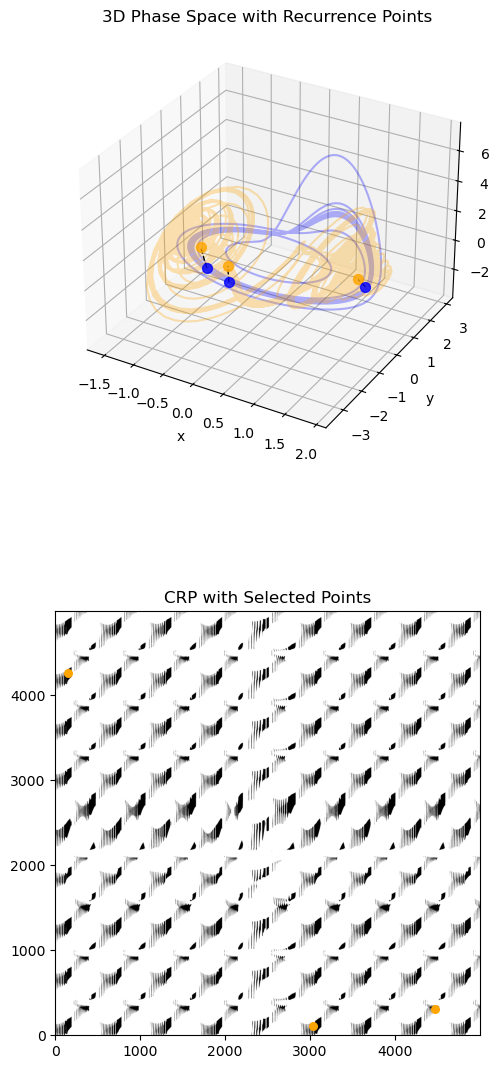

In [ ]:
#PLOT PHASE SPACE + CRP WITH RECURRENCE POINTS

# pairs = [(2000, 1000), (300, 340), (4000, 100)]
# randomly pick 3 pairs
recurrence_indices = np.argwhere(CR_gs == 1) #for generalized synchronization
np.random.seed(0)
selected = recurrence_indices[np.random.choice(len(recurrence_indices), 3, replace=False)]
pairs = [(i, j) for i, j in selected]

fig = plt.figure(figsize=(5, 12))

# UPPER: Phase Space

ax1 = fig.add_subplot(2, 1, 1, projection='3d')

# trajectories
ax1.plot(ts1_gs[:, 0], ts1_gs[:, 1], ts1_gs[:, 2],
         color='blue', alpha=0.3)

ax1.plot(ts2_gs[:, 0], ts2_gs[:, 1], ts2_gs[:, 2],
         color='orange', alpha=0.3)

# plot recurrence points
for k, (i, j) in enumerate(pairs):
    # point i
    ax1.scatter(ts1_gs[i, 0], ts1_gs[i, 1], ts1_gs[i, 2],
                color='blue', s=50, alpha=0.8)

    # point j
    ax1.scatter(ts2_gs[j, 0], ts2_gs[j, 1], ts2_gs[j, 2],
                color='orange', s=50, alpha=0.8)

    # connect them (optional, VERY insightful)
    ax1.plot([ts1_gs[i, 0], ts2_gs[j, 0]],
             [ts1_gs[i, 1], ts2_gs[j, 1]],
             [ts1_gs[i, 2], ts2_gs[j, 2]],
             color='black', linestyle='--', linewidth=1)

ax1.set_title("3D Phase Space with Recurrence Points")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

# LOWER: CRP

ax2 = fig.add_subplot(2, 1, 2)

ax2.imshow(CR_gs, origin='lower', cmap='binary')

# mark same points in CRP
for (i, j) in pairs:
    ax2.scatter(j, i, color='orange', s=30, alpha=1.0)  # note: (col=j, row=i)

ax2.set_title("CRP with Selected Points")

plt.tight_layout()
plt.show()

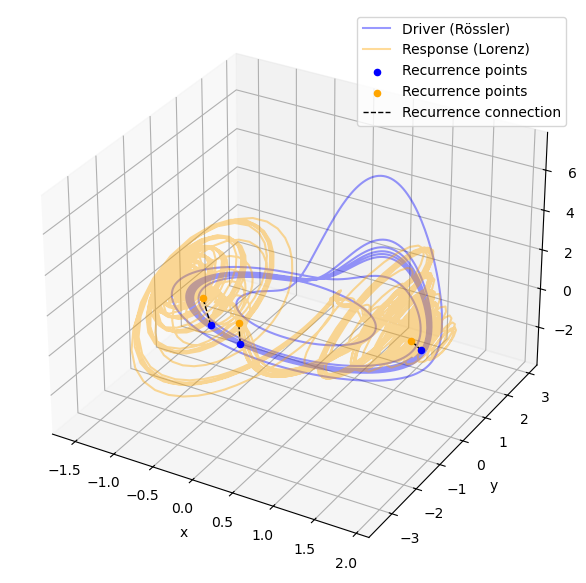

In [ ]:
# PLOT PHASE SPACE ONLY(GS)

# PICK 3 RECURRENCE PAIRS
recurrence_indices = np.argwhere(CR_gs == 1)
np.random.seed(0)  
selected = recurrence_indices[
    np.random.choice(len(recurrence_indices), 3, replace=False)
]
pairs = [(i, j) for i, j in selected]

fig1 = plt.figure(figsize=(6, 6))
ax1 = fig1.add_subplot(111, projection='3d')

# trajectories (add labels here)
ax1.plot(ts1_gs[:, 0], ts1_gs[:, 1], ts1_gs[:, 2],
         color='blue', alpha=0.4, label='Driver (Rössler)')

ax1.plot(ts2_gs[:, 0], ts2_gs[:, 1], ts2_gs[:, 2],
         color='orange', alpha=0.4, label='Response (Lorenz)')


# PLOT
for k, (i, j) in enumerate(pairs):
    # only label ONCE to avoid duplicates
    label1 = 'Recurrence points' if k == 0 else None
    label2 = 'Recurrence points' if k == 0 else None
    label_link = 'Recurrence connection' if k == 0 else None

    ax1.scatter(ts1_gs[i, 0], ts1_gs[i, 1], ts1_gs[i, 2],
                color='blue', s=20, label=label1)

    ax1.scatter(ts2_gs[j, 0], ts2_gs[j, 1], ts2_gs[j, 2],
                color='orange', s=20, label=label2)

    ax1.plot([ts1_gs[i, 0], ts2_gs[j, 0]],
             [ts1_gs[i, 1], ts2_gs[j, 1]],
             [ts1_gs[i, 2], ts2_gs[j, 2]],
             color='black', linestyle='--', linewidth=1,
             label=label_link)

ax1.legend(loc='best')

# ax1.set_title("3D Phase Space with Recurrence Points")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("z")

#savefigure
plt.savefig("Phase_space_GS.pdf", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

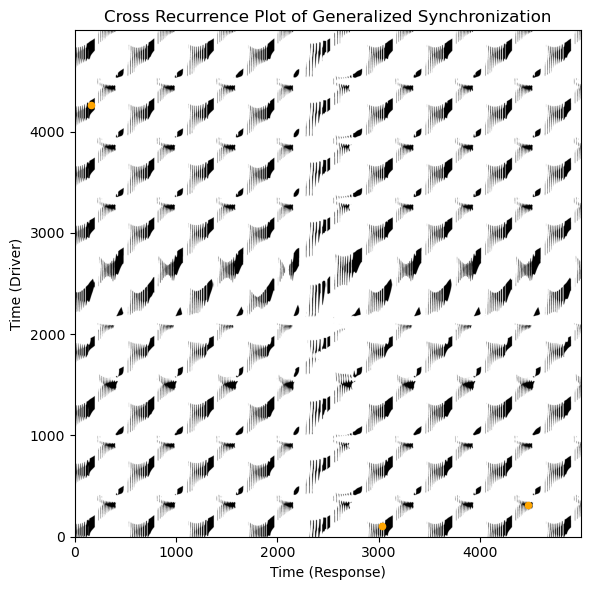

In [ ]:
#USE THE SAME PAIRS WITH PHASE SPACE PLOT
#PLOT CRP WITH RECURRENCE POINTS (GS)
fig2 = plt.figure(figsize=(6, 6))
ax2 = fig2.add_subplot(111)

ax2.imshow(CR_gs, origin='lower', cmap='binary')
# mark same recurrence pairs
for (i, j) in pairs:
    ax2.scatter(j, i, color='orange', s=20)

ax2.set_title("Cross Recurrence Plot of Generalized Synchronization")
ax2.set_xlabel("Time (Response)")
ax2.set_ylabel("Time (Driver)")
#savefig
plt.savefig("CRP_GS.pdf", dpi=300, bbox_inches='tight')
plt.tight_layout()
plt.show()

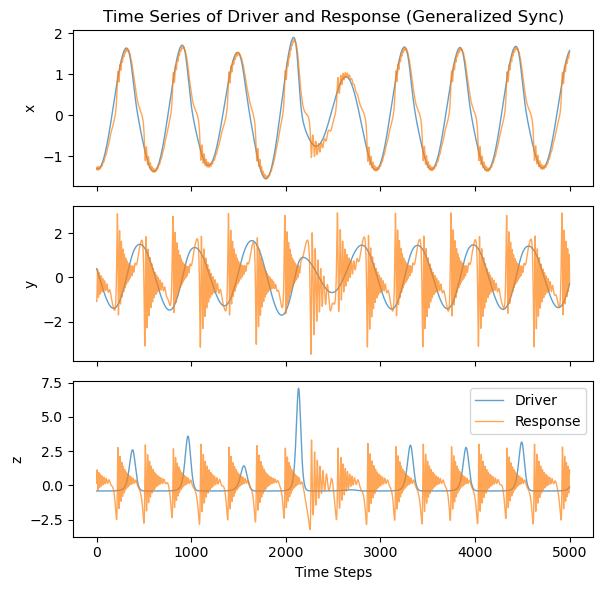

In [ ]:
#plot time series for generalized synchronization case
fig, axes = plt.subplots(3, 1, figsize=(6,6), sharex=True)

# plot time series
axes[0].plot(ts1_gs[:, 0], label='Driver x', alpha=0.7, linewidth=1)
axes[0].plot(ts2_gs[:, 0], label='Response x', alpha=0.7, linewidth=1)
axes[1].plot(ts1_gs[:, 1], label='Driver y', alpha=0.7, linewidth=1)
axes[1].plot(ts2_gs[:, 1], label='Response y', alpha=0.7, linewidth=1)
axes[2].plot(ts1_gs[:, 2], label='Driver', alpha=0.7, linewidth=1)
axes[2].plot(ts2_gs[:, 2], label='Response', alpha=0.7, linewidth=1)

axes[0].set_title("Time Series of Driver and Response (Generalized Sync)")
axes[2].set_xlabel("Time Steps")
axes[0].set_ylabel("x")
axes[1].set_ylabel("y")
axes[2].set_ylabel("z") 

axes[2].legend(loc='upper right')
plt.savefig("generalized_sync_time_series.pdf", dpi=300)
plt.tight_layout()
plt.show()

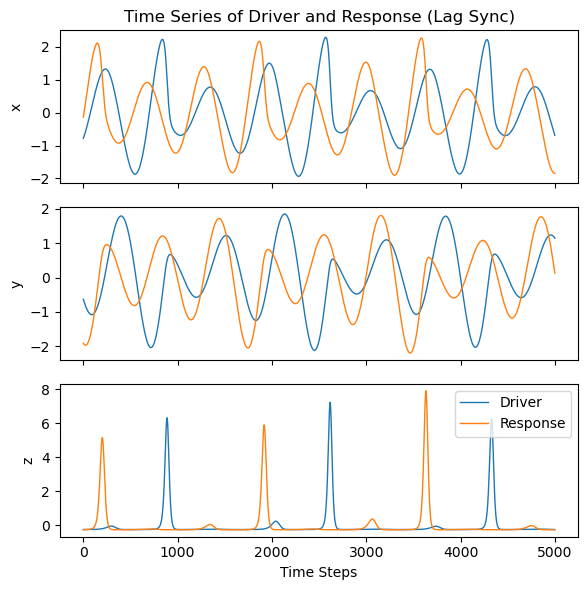

In [11]:
#plot time series for lag synchronization case
fig, axes = plt.subplots(3, 1, figsize=(6,6), sharex=True)

# plot time series
axes[0].plot(ts1_ls[:, 0], label='Driver x', alpha=1.0, linewidth=1)
axes[0].plot(ts2_ls[:, 0], label='Response x', alpha=1.0, linewidth=1)
axes[1].plot(ts1_ls[:, 1], label='Driver y', alpha=1.0, linewidth=1)
axes[1].plot(ts2_ls[:, 1], label='Response y', alpha=1.0, linewidth=1)
axes[2].plot(ts1_ls[:, 2], label='Driver', alpha=1.0, linewidth=1)
axes[2].plot(ts2_ls[:, 2], label='Response', alpha=1.0, linewidth=1)

axes[0].set_title("Time Series of Driver and Response (Lag Sync)")
axes[2].set_xlabel("Time Steps")
axes[0].set_ylabel("x")
axes[1].set_ylabel("y")
axes[2].set_ylabel("z") 

axes[2].legend(loc='upper right')
plt.savefig("lag_sync_time_series.pdf", dpi=300)
plt.tight_layout()
plt.show()

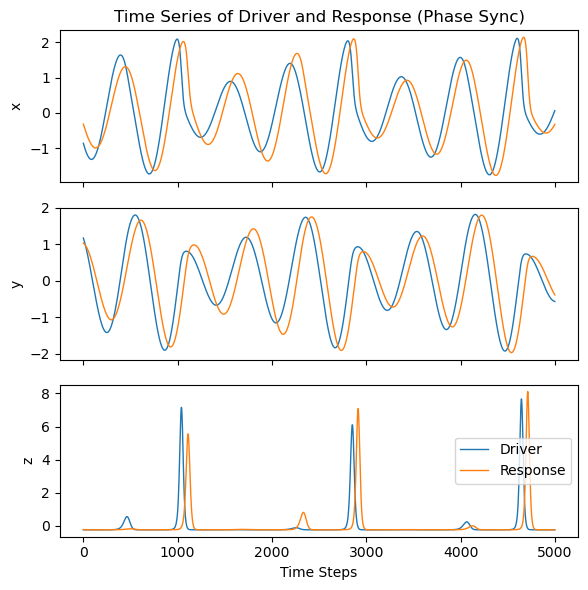

In [12]:
#plot time series for lag synchronization case
fig, axes = plt.subplots(3, 1, figsize=(6, 6), sharex=True)

# plot time series
axes[0].plot(ts1_ps[:, 0], label='Driver x', alpha=1.0, linewidth=1)
axes[0].plot(ts2_ps[:, 0], label='Response x', alpha=1.0, linewidth=1)
axes[1].plot(ts1_ps[:, 1], label='Driver y', alpha=1.0, linewidth=1)
axes[1].plot(ts2_ps[:, 1], label='Response y', alpha=1.0, linewidth=1)
axes[2].plot(ts1_ps[:, 2], label='Driver', alpha=1.0, linewidth=1)
axes[2].plot(ts2_ps[:, 2], label='Response', alpha=1.0, linewidth=1)

axes[0].set_title("Time Series of Driver and Response (Phase Sync)")
axes[2].set_xlabel("Time Steps")
axes[0].set_ylabel("x")
axes[1].set_ylabel("y")
axes[2].set_ylabel("z") 

axes[2].legend(loc='center right')
plt.savefig("phase_sync_time_series.pdf", dpi=300)
plt.tight_layout()
plt.show()